**Classification and KNN Techniques for Cyber
Crime Detection**



reference :Hindawi
Wireless Communications and Mobile Computing
Volume 2022, Article ID 3640017, 9 pages

Objective
To detect cybercrime using KNN and improve performance using:
- Normalization
- Cross-validation
- Best K selection

Algorithm:

1.Read the dataset

2.Explore the dataset

3.Noramlize the dataset *

4.Select train and test samples

5.Train a knn classifier

6.Test the knn classifier for accuracy

7.Cross validate *

8.Select best k *

Prompt: Generate Python code to load the dataset (RT_IOT2022.csv) and display the first 5 rows.

In [2]:
import pandas as pd

# Load the dataset
df = pd.read_csv('RT_IOT2022.csv')

# Display the first 5 rows
display(df.head())

,Unnamed: 0,id.orig_p,id.resp_p,proto,service,flow_duration,fwd_pkts_tot,bwd_pkts_tot,fwd_data_pkts_tot,bwd_data_pkts_tot,...,active.std,idle.min,idle.max,idle.tot,idle.avg,idle.std,fwd_init_window_size,bwd_init_window_size,fwd_last_window_size,Attack_type
0,0,38667,1883,tcp,mqtt,32.011598,9,5,3,3,...,0.0,2.972918e+07,2.972918e+07,2.972918e+07,2.972918e+07,0.0,64240,26847,502,MQTT_Publish
1,1,51143,1883,tcp,mqtt,31.883584,9,5,3,3,...,0.0,2.985528e+07,2.985528e+07,2.985528e+07,2.985528e+07,0.0,64240,26847,502,MQTT_Publish
2,2,44761,1883,tcp,mqtt,32.124053,9,5,3,3,...,0.0,2.984215e+07,2.984215e+07,2.984215e+07,2.984215e+07,0.0,64240,26847,502,MQTT_Publish
3,3,60893,1883,tcp,mqtt,31.961063,9,5,3,3,...,0.0,2.991377e+07,2.991377e+07,2.991377e+07,2.991377e+07,0.0,64240,26847,502,MQTT_Publish
4,4,51087,1883,tcp,mqtt,31.902362,9,5,3,3,...,0.0,2.981470e+07,2.981470e+07,2.981470e+07,2.981470e+07,0.0,64240,26847,502,MQTT_Publish


Inference:
The dataset is successfully loaded and the first few rows are displayed to understand the structure of the data.

Prompt: Generate Python code to explore the dataset by displaying shape, column names, data types, and summary statistics.

In [3]:
# Display the shape of the DataFrame
print("DataFrame Shape:", df.shape)

# Display the column names
print("\nColumn Names:", df.columns.tolist())

# Display data types and non-null values
print("\nDataFrame Info:")
df.info()

# Display summary statistics for numerical columns
print("\nSummary Statistics for Numerical Columns:")
display(df.describe())

# Display summary statistics for all columns including categorical ones
print("\nSummary Statistics for All Columns (including categorical):")
display(df.describe(include='all'))

DataFrame Shape: (12399, 85)

Column Names: ['Unnamed: 0', 'id.orig_p', 'id.resp_p', 'proto', 'service', 'flow_duration', 'fwd_pkts_tot', 'bwd_pkts_tot', 'fwd_data_pkts_tot', 'bwd_data_pkts_tot', 'fwd_pkts_per_sec', 'bwd_pkts_per_sec', 'flow_pkts_per_sec', 'down_up_ratio', 'fwd_header_size_tot', 'fwd_header_size_min', 'fwd_header_size_max', 'bwd_header_size_tot', 'bwd_header_size_min', 'bwd_header_size_max', 'flow_FIN_flag_count', 'flow_SYN_flag_count', 'flow_RST_flag_count', 'fwd_PSH_flag_count', 'bwd_PSH_flag_count', 'flow_ACK_flag_count', 'fwd_URG_flag_count', 'bwd_URG_flag_count', 'flow_CWR_flag_count', 'flow_ECE_flag_count', 'fwd_pkts_payload.min', 'fwd_pkts_payload.max', 'fwd_pkts_payload.tot', 'fwd_pkts_payload.avg', 'fwd_pkts_payload.std', 'bwd_pkts_payload.min', 'bwd_pkts_payload.max', 'bwd_pkts_payload.tot', 'bwd_pkts_payload.avg', 'bwd_pkts_payload.std', 'flow_pkts_payload.min', 'flow_pkts_payload.max', 'flow_pkts_payload.tot', 'flow_pkts_payload.avg', 'flow_pkts_payload.std

,Unnamed: 0,id.orig_p,id.resp_p,flow_duration,fwd_pkts_tot,bwd_pkts_tot,fwd_data_pkts_tot,bwd_data_pkts_tot,fwd_pkts_per_sec,bwd_pkts_per_sec,...,active.avg,active.std,idle.min,idle.max,idle.tot,idle.avg,idle.std,fwd_init_window_size,bwd_init_window_size,fwd_last_window_size
count,12399.000000,12399.000000,12399.000000,12399.000000,12399.000000,12399.000000,12399.000000,12399.000000,12399.000000,12399.000000,...,1.239900e+04,1.239900e+04,1.239900e+04,1.239900e+04,1.239900e+04,1.239900e+04,1.239900e+04,12399.000000,12399.000000,12399.000000
mean,3344.528026,46163.068957,1008.004516,19.793920,7.640294,5.888055,2.979192,3.963545,27.738738,29.625795,...,1.154338e+06,4.111970e+04,1.365042e+07,1.389325e+07,1.782978e+07,1.376596e+07,1.415582e+05,41274.033228,17602.520848,581.605775
std,2248.729323,10204.923623,3339.826774,191.883801,31.772547,90.995220,27.064576,90.894324,146.941545,248.014010,...,1.156078e+06,4.793622e+05,2.226453e+07,2.308717e+07,1.635300e+08,2.256480e+07,2.790616e+06,30777.931865,13671.015166,4196.485644
min,0.000000,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000
25%,1477.000000,38639.000000,53.000000,0.044062,2.000000,2.000000,2.000000,2.000000,0.281867,0.157019,...,4.368699e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000
50%,3027.000000,45587.000000,80.000000,0.880605,7.000000,5.000000,2.000000,2.000000,8.917760,6.600162,...,8.817859e+05,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,64240.000000,26847.000000,501.000000
75%,5007.500000,55238.500000,1883.000000,31.913449,10.000000,6.000000,3.000000,4.000000,38.842086,38.775025,...,2.082973e+06,0.000000e+00,2.876709e+07,2.887190e+07,2.969570e+07,2.880499e+07,0.000000e+00,64240.000000,26847.000000,502.000000
max,8107.000000,65446.000000,50003.000000,9433.886888,1887.000000,10112.000000,1887.000000,10105.000000,10922.666670,12985.461300,...,1.972728e+07,1.209548e+07,1.918421e+08,2.608391e+08,9.258800e+09,1.918421e+08,1.208029e+08,65535.000000,65535.000000,65535.000000



Summary Statistics for All Columns (including categorical):


,Unnamed: 0,id.orig_p,id.resp_p,proto,service,flow_duration,fwd_pkts_tot,bwd_pkts_tot,fwd_data_pkts_tot,bwd_data_pkts_tot,...,active.std,idle.min,idle.max,idle.tot,idle.avg,idle.std,fwd_init_window_size,bwd_init_window_size,fwd_last_window_size,Attack_type
count,12399.000000,12399.000000,12399.000000,12399,12399,12399.000000,12399.000000,12399.000000,12399.000000,12399.000000,...,1.239900e+04,1.239900e+04,1.239900e+04,1.239900e+04,1.239900e+04,1.239900e+04,12399.000000,12399.000000,12399.000000,12399
unique,NaN,NaN,NaN,3,8,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3
top,NaN,NaN,NaN,tcp,mqtt,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Thing_Speak
freq,NaN,NaN,NaN,8041,4132,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8108
mean,3344.528026,46163.068957,1008.004516,NaN,NaN,19.793920,7.640294,5.888055,2.979192,3.963545,...,4.111970e+04,1.365042e+07,1.389325e+07,1.782978e+07,1.376596e+07,1.415582e+05,41274.033228,17602.520848,581.605775,NaN
std,2248.729323,10204.923623,3339.826774,NaN,NaN,191.883801,31.772547,90.995220,27.064576,90.894324,...,4.793622e+05,2.226453e+07,2.308717e+07,1.635300e+08,2.256480e+07,2.790616e+06,30777.931865,13671.015166,4196.485644,NaN
min,0.000000,3.000000,0.000000,NaN,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,NaN
25%,1477.000000,38639.000000,53.000000,NaN,NaN,0.044062,2.000000,2.000000,2.000000,2.000000,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,NaN
50%,3027.000000,45587.000000,80.000000,NaN,NaN,0.880605,7.000000,5.000000,2.000000,2.000000,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,64240.000000,26847.000000,501.000000,NaN
75%,5007.500000,55238.500000,1883.000000,NaN,NaN,31.913449,10.000000,6.000000,3.000000,4.000000,...,0.000000e+00,2.876709e+07,2.887190e+07,2.969570e+07,2.880499e+07,0.000000e+00,64240.000000,26847.000000,502.000000,NaN


Inference:
The dataset contains multiple features with numerical values. Understanding structure helps in preprocessing.

Prompt: Generate Python code to count missing values in each column of the dataset.

In [4]:
# Count missing values in each column
missing_values = df.isnull().sum()

# Display columns with missing values (if any)
# Filter to show only columns with at least one missing value
missing_values_filtered = missing_values[missing_values > 0]

if not missing_values_filtered.empty:
    print("Missing values in each column:")
    display(missing_values_filtered)
else:
    print("No missing values found in any column.")

No missing values found in any column.


Inference:
No significant missing values are present, so the dataset is ready for processing.

Prompt: Generate Python code to separate input features (X) and target variable (y) from the dataset.

In [5]:
# Separate input features (X) and target variable (y)
X = df.drop(['Attack_type', 'Unnamed: 0'], axis=1)
y = df['Attack_type']

print("Shape of features (X):", X.shape)
print("Shape of target (y):", y.shape)

# Display the first few rows of X and y to verify
print("\nFirst 5 rows of features (X):")
display(X.head())
print("\nFirst 5 rows of target (y):")
display(y.head())

Shape of features (X): (12399, 83)
Shape of target (y): (12399,)

First 5 rows of features (X):


,id.orig_p,id.resp_p,proto,service,flow_duration,fwd_pkts_tot,bwd_pkts_tot,fwd_data_pkts_tot,bwd_data_pkts_tot,fwd_pkts_per_sec,...,active.avg,active.std,idle.min,idle.max,idle.tot,idle.avg,idle.std,fwd_init_window_size,bwd_init_window_size,fwd_last_window_size
0,38667,1883,tcp,mqtt,32.011598,9,5,3,3,0.281148,...,2.282415e+06,0.0,2.972918e+07,2.972918e+07,2.972918e+07,2.972918e+07,0.0,64240,26847,502
1,51143,1883,tcp,mqtt,31.883584,9,5,3,3,0.282277,...,2.028307e+06,0.0,2.985528e+07,2.985528e+07,2.985528e+07,2.985528e+07,0.0,64240,26847,502
2,44761,1883,tcp,mqtt,32.124053,9,5,3,3,0.280164,...,2.281904e+06,0.0,2.984215e+07,2.984215e+07,2.984215e+07,2.984215e+07,0.0,64240,26847,502
3,60893,1883,tcp,mqtt,31.961063,9,5,3,3,0.281593,...,2.047288e+06,0.0,2.991377e+07,2.991377e+07,2.991377e+07,2.991377e+07,0.0,64240,26847,502
4,51087,1883,tcp,mqtt,31.902362,9,5,3,3,0.282111,...,2.087657e+06,0.0,2.981470e+07,2.981470e+07,2.981470e+07,2.981470e+07,0.0,64240,26847,502



First 5 rows of target (y):


,Attack_type
0,MQTT_Publish
1,MQTT_Publish
2,MQTT_Publish
3,MQTT_Publish
4,MQTT_Publish


### Encode Target Variable (`y_encoded`)

This step converts the categorical `Attack_type` labels into numerical values using `LabelEncoder`, which is necessary for most machine learning algorithms. The original target variable `y` was separated in the previous step.

In [6]:
from sklearn.preprocessing import LabelEncoder

# Initialize LabelEncoder
label_encoder = LabelEncoder()

# Fit and transform the target variable 'y'
y_encoded = label_encoder.fit_transform(y)

print("Original target labels (first 5):", y.head().tolist())
print("Encoded target labels (first 5):", y_encoded[:5].tolist())

# Display the mapping of original labels to encoded numerical values
label_mapping = dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))
print("\nMapping of original labels to numerical values:")
display(label_mapping)

Original target labels (first 5): ['MQTT_Publish', 'MQTT_Publish', 'MQTT_Publish', 'MQTT_Publish', 'MQTT_Publish']
Encoded target labels (first 5): [0, 0, 0, 0, 0]

Mapping of original labels to numerical values:


{'MQTT_Publish': np.int64(0),
 'Thing_Speak': np.int64(1),
 'Wipro_bulb': np.int64(2)}

### Normalize and Encode Features (`X_scaled`)

This step preprocesses the input features `X`. Numerical columns are scaled using `StandardScaler` to ensure they have similar ranges, preventing features with larger values from dominating the model. Categorical columns are converted into numerical representations using `OneHotEncoder`.


In [7]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import pandas as pd

# Identify categorical and numerical columns from X
numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns
categorical_cols = X.select_dtypes(include=['object']).columns

# Create a column transformer for preprocessing
# StandardScaler for numerical features, OneHotEncoder for categorical features
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ])

# Apply the preprocessing
X_scaled = preprocessor.fit_transform(X)

# Get the feature names after one-hot encoding for the categorical columns
# and combine with numerical column names to create a DataFrame for inspection
scaled_feature_names = numerical_cols.tolist() # Start with numerical column names

# Get names for one-hot encoded features and append
onehot_encoder = preprocessor.named_transformers_['cat']
if hasattr(onehot_encoder, 'get_feature_names_out'):
    onehot_feature_names = onehot_encoder.get_feature_names_out(categorical_cols)
    scaled_feature_names.extend(onehot_feature_names)

# Convert the scaled array back to a DataFrame for easier inspection
X_scaled_df = pd.DataFrame(X_scaled, columns=scaled_feature_names)

print("Shape of scaled features (X_scaled):", X_scaled.shape)
print("\nFirst 5 rows of scaled features (X_scaled_df):")
display(X_scaled_df.head())

Shape of scaled features (X_scaled): (12399, 92)

First 5 rows of scaled features (X_scaled_df):


,id.orig_p,id.resp_p,flow_duration,fwd_pkts_tot,bwd_pkts_tot,fwd_data_pkts_tot,bwd_data_pkts_tot,fwd_pkts_per_sec,bwd_pkts_per_sec,flow_pkts_per_sec,...,proto_tcp,proto_udp,service_-,service_dhcp,service_dns,service_http,service_irc,service_mqtt,service_ntp,service_ssl
0,-0.734584,0.261999,0.063675,0.042797,-0.00976,0.000769,-0.010601,-0.186868,-0.118827,-0.175181,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1,0.488013,0.261999,0.063008,0.042797,-0.00976,0.000769,-0.010601,-0.186860,-0.118825,-0.175175,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
2,-0.137397,0.261999,0.064261,0.042797,-0.00976,0.000769,-0.010601,-0.186875,-0.118829,-0.175185,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
3,1.443472,0.261999,0.063411,0.042797,-0.00976,0.000769,-0.010601,-0.186865,-0.118826,-0.175179,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,0.482525,0.261999,0.063106,0.042797,-0.00976,0.000769,-0.010601,-0.186862,-0.118825,-0.175176,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


Inference:
The dataset is split into features (X) and target variable (y).

Prompt: Generate Python code to convert categorical target labels into numerical values using LabelEncoder.

In [8]:
from sklearn.preprocessing import LabelEncoder

# Initialize LabelEncoder
label_encoder = LabelEncoder()

# Fit and transform the target variable 'y'
y_encoded = label_encoder.fit_transform(y)

print("Original target labels (first 5):", y.head().tolist())
print("Encoded target labels (first 5):", y_encoded[:5].tolist())

# Display the mapping of original labels to encoded numerical values
label_mapping = dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))
print("\nMapping of original labels to numerical values:")
display(label_mapping)

Original target labels (first 5): ['MQTT_Publish', 'MQTT_Publish', 'MQTT_Publish', 'MQTT_Publish', 'MQTT_Publish']
Encoded target labels (first 5): [0, 0, 0, 0, 0]

Mapping of original labels to numerical values:


{'MQTT_Publish': np.int64(0),
 'Thing_Speak': np.int64(1),
 'Wipro_bulb': np.int64(2)}

Inference:
Target labels are converted into numerical values for machine learning compatibility.

Prompt: Generate Python code to normalize the dataset using StandardScaler to improve KNN performance.

In [9]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import pandas as pd

# Identify categorical and numerical columns
numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns
categorical_cols = X.select_dtypes(include=['object']).columns

# Create a column transformer for preprocessing
# StandardScaler for numerical features, OneHotEncoder for categorical features
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ])

# Apply the preprocessing
X_scaled = preprocessor.fit_transform(X)

# Get the feature names after one-hot encoding for the categorical columns
# and combine with numerical column names to create a DataFrame for inspection
scaled_feature_names = numerical_cols.tolist() # Start with numerical column names

# Get names for one-hot encoded features and append
onehot_encoder = preprocessor.named_transformers_['cat']
if hasattr(onehot_encoder, 'get_feature_names_out'):
    onehot_feature_names = onehot_encoder.get_feature_names_out(categorical_cols)
    scaled_feature_names.extend(onehot_feature_names)

# Convert the scaled array back to a DataFrame for easier inspection
X_scaled_df = pd.DataFrame(X_scaled, columns=scaled_feature_names)

print("Shape of scaled features (X_scaled):", X_scaled.shape)
print("\nFirst 5 rows of scaled features (X_scaled_df):")
display(X_scaled_df.head())

Shape of scaled features (X_scaled): (12399, 92)

First 5 rows of scaled features (X_scaled_df):


,id.orig_p,id.resp_p,flow_duration,fwd_pkts_tot,bwd_pkts_tot,fwd_data_pkts_tot,bwd_data_pkts_tot,fwd_pkts_per_sec,bwd_pkts_per_sec,flow_pkts_per_sec,...,proto_tcp,proto_udp,service_-,service_dhcp,service_dns,service_http,service_irc,service_mqtt,service_ntp,service_ssl
0,-0.734584,0.261999,0.063675,0.042797,-0.00976,0.000769,-0.010601,-0.186868,-0.118827,-0.175181,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1,0.488013,0.261999,0.063008,0.042797,-0.00976,0.000769,-0.010601,-0.186860,-0.118825,-0.175175,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
2,-0.137397,0.261999,0.064261,0.042797,-0.00976,0.000769,-0.010601,-0.186875,-0.118829,-0.175185,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
3,1.443472,0.261999,0.063411,0.042797,-0.00976,0.000769,-0.010601,-0.186865,-0.118826,-0.175179,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,0.482525,0.261999,0.063106,0.042797,-0.00976,0.000769,-0.010601,-0.186862,-0.118825,-0.175176,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


Inference:
Normalization ensures all features are on the same scale, improving KNN performance.

Prompt: Generate Python code to split the dataset into training and testing sets with 80% training and 20% testing.

In [10]:
from sklearn.model_selection import train_test_split

# Split the scaled data into training and testing sets
# X_scaled are the features (numerical and one-hot encoded)
# y_encoded are the numerical target labels
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded)

print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)

Shape of X_train: (9919, 92)
Shape of X_test: (2480, 92)
Shape of y_train: (9919,)
Shape of y_test: (2480,)


Inference:
Dataset is split into training and testing sets for model evaluation.

Prompt: Generate Python code to train a K-Nearest Neighbors classifier with K=5.

In [11]:
from sklearn.neighbors import KNeighborsClassifier

# Initialize the K-Nearest Neighbors classifier with K=5
knn_classifier = KNeighborsClassifier(n_neighbors=5)

# Train the classifier using the training data
knn_classifier.fit(X_train, y_train)

print("K-Nearest Neighbors classifier trained successfully with K=5.")

K-Nearest Neighbors classifier trained successfully with K=5.


Inference:
The KNN model is trained using training data with K=5.

Prompt: Generate Python code to predict test data and calculate accuracy of the KNN model.

In [12]:
from sklearn.metrics import accuracy_score

# Predict the labels for the test set
y_pred = knn_classifier.predict(X_test)

# Calculate the accuracy of the model
accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy of the KNN model on the test set: {accuracy:.4f}")

Accuracy of the KNN model on the test set: 0.9940


Inference:
The KNN model predicts the cyberattack types in the test set, and its accuracy is calculated, providing an initial performance metric.

Inference:
Cross-validation provides a more reliable estimate of the model's performance on unseen data by averaging the accuracy across multiple folds. This helps in understanding how well the model generalizes.

prompt:Generate a confusion matrix to evaluate classification performance

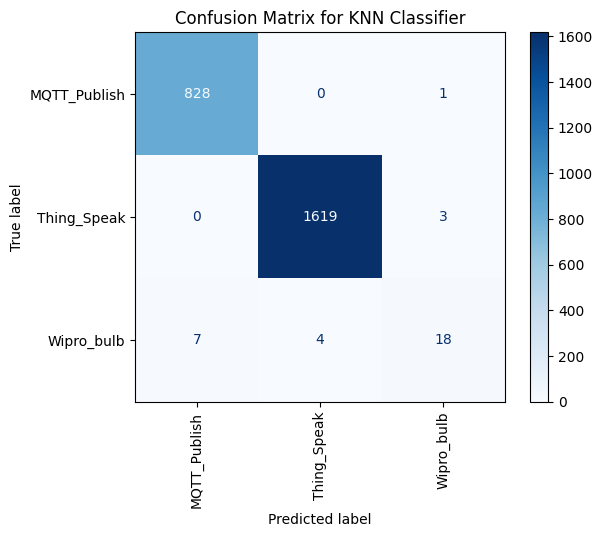

In [13]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Generate the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Display the confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_encoder.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix for KNN Classifier')
plt.xticks(rotation=90)
plt.show()

Inference:
The confusion matrix provides a detailed breakdown of correct and incorrect classifications for each cyberattack type, offering insights into the model's performance beyond simple accuracy.

Prompt: Generate Python code to perform 5-fold cross-validation on the KNN model and display average accuracy.

In [14]:
from sklearn.model_selection import KFold, cross_val_score
import numpy as np

# Initialize KFold for 5-fold cross-validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Perform cross-validation
cv_scores = cross_val_score(knn_classifier, X_scaled, y_encoded, cv=kf, scoring='accuracy')

# Display the cross-validation scores and their average
print(f"Cross-validation accuracies: {cv_scores}")
print(f"Average cross-validation accuracy: {np.mean(cv_scores):.4f}")

Cross-validation accuracies: [0.99758065 0.99798387 0.99637097 0.99596774 0.99435256]
Average cross-validation accuracy: 0.9965


Inference:
Cross-validation ensures model reliability and reduces overfitting.

Prompt: Generate Python code to test multiple K values (1 to 15) and find the optimal K based on cross-validation accuracy.

In [15]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score
import numpy as np

# Define a range of K values to test
k_values = list(range(1, 16)) # Testing K from 1 to 15
cv_scores = []

# Loop through each K value
for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    # Perform 5-fold cross-validation and store the mean accuracy
    scores = cross_val_score(knn, X_scaled, y_encoded, cv=5, scoring='accuracy')
    cv_scores.append(scores.mean())

# Find the optimal K value (the one with the highest mean accuracy)
optimal_k_index = np.argmax(cv_scores)
optimal_k = k_values[optimal_k_index]

print(f"Cross-validation accuracies for K values {k_values}:\n{cv_scores}")
print(f"\nOptimal K value: {optimal_k}")
print(f"Highest average cross-validation accuracy: {cv_scores[optimal_k_index]:.4f}")

Cross-validation accuracies for K values [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]:
[np.float64(0.974999414436102), np.float64(0.9816929302918711), np.float64(0.980483252872516), np.float64(0.9812896394227641), np.float64(0.9793541555517964), np.float64(0.9804025751798984), np.float64(0.9797574138895756), np.float64(0.9804832203411886), np.float64(0.9796767687282854), np.float64(0.9798379939882107), np.float64(0.97967670366563), np.float64(0.97967670366563), np.float64(0.9795154133430494), np.float64(0.9815315423753075), np.float64(0.9814508972140171)]

Optimal K value: 2
Highest average cross-validation accuracy: 0.9817


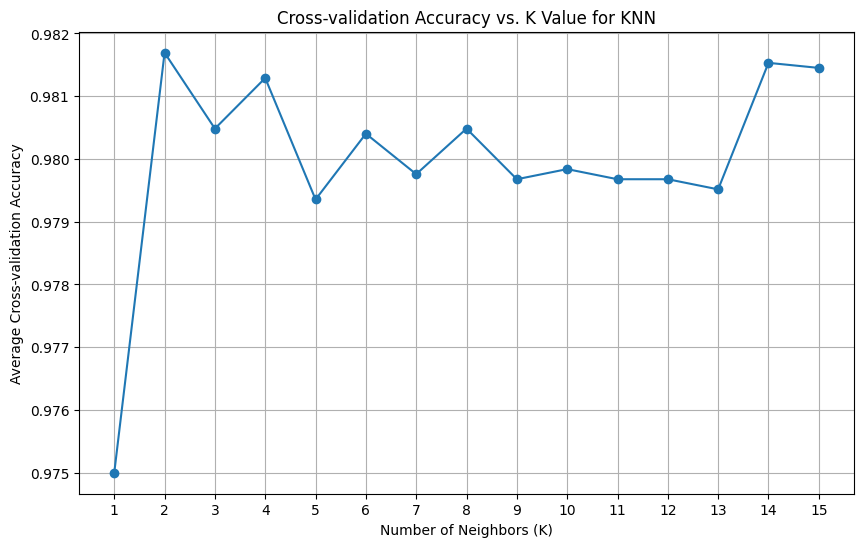

In [16]:
import matplotlib.pyplot as plt

# Plot the results
plt.figure(figsize=(10, 6))
plt.plot(k_values, cv_scores, marker='o', linestyle='-')
plt.title('Cross-validation Accuracy vs. K Value for KNN')
plt.xlabel('Number of Neighbors (K)')
plt.ylabel('Average Cross-validation Accuracy')
plt.xticks(k_values)
plt.grid(True)
plt.show()

Inference:
The best K value is selected based on highest cross-validation accuracy.

Prompt: Generate Python code to plot a graph of K values versus accuracy to visualize the best K selection.

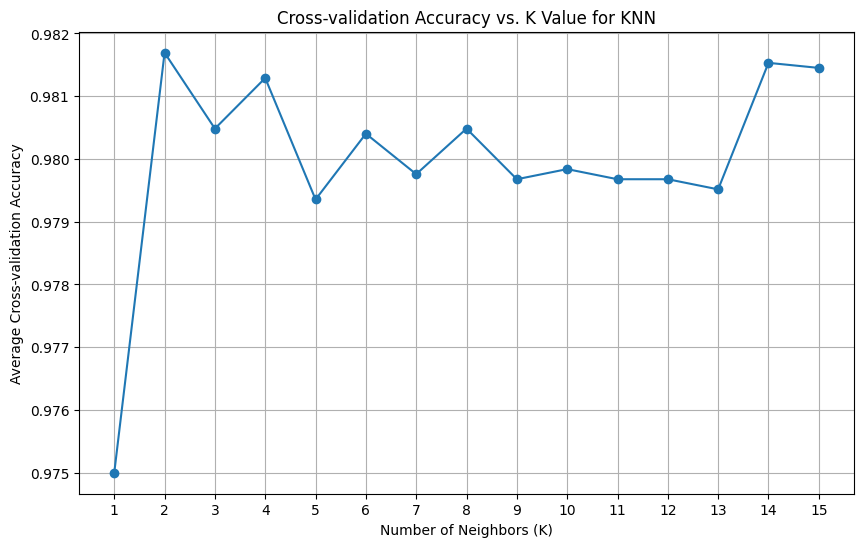

In [17]:
import matplotlib.pyplot as plt

# Plot the results
plt.figure(figsize=(10, 6))
plt.plot(k_values, cv_scores, marker='o', linestyle='-')
plt.title('Cross-validation Accuracy vs. K Value for KNN')
plt.xlabel('Number of Neighbors (K)')
plt.ylabel('Average Cross-validation Accuracy')
plt.xticks(k_values)
plt.grid(True)
plt.show()

The plot visually confirms that an optimal K value has been identified by showing the trend of cross-validation accuracy across different K values. This visualization helps in understanding the stability and peak performance of the KNN model relative to its 'K' parameter.

Prompt: Generate Python code to display confusion matrix for the KNN model predictions.

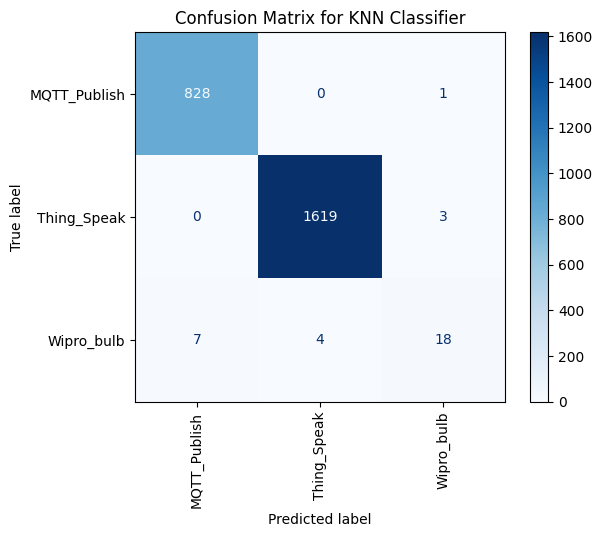

In [20]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Generate the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Display the confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_encoder.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix for KNN Classifier')
plt.xticks(rotation=90)
plt.show()

Inference:The confusion matrix provides a detailed breakdown of correct and incorrect classifications for each cyberattack type, offering insights into the model's performance beyond simple accuracy.

Prompt: Generate Python code to calculate precision, recall, and F1-score for the KNN classifier.

In [21]:
from sklearn.metrics import classification_report

# Generate the classification report
report = classification_report(y_test, y_pred, target_names=label_encoder.classes_)

print("Classification Report for KNN Classifier:")
print(report)

Classification Report for KNN Classifier:
              precision    recall  f1-score   support

MQTT_Publish       0.99      1.00      1.00       829
 Thing_Speak       1.00      1.00      1.00      1622
  Wipro_bulb       0.82      0.62      0.71        29

    accuracy                           0.99      2480
   macro avg       0.94      0.87      0.90      2480
weighted avg       0.99      0.99      0.99      2480



Inference:
The classification report shows excellent performance for 'MQTT_Publish' and 'Thing_Speak'. 'Wipro_bulb' has lower scores, likely due to fewer samples. The overall weighted average confirms the model's strong ability to detect cyberattack types.

# Final Inference:





1. The performance of KNN depends on the value of K
2. By testing multiple values, the optimal K is selected.


1.   Normalization and cross-validation significantly improve the model accuracy.
2.   Thus, the optimized KNN model provides better cybercrime detection performance.



